In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from omegaconf import OmegaConf

import bbrl_utils
from bbrl_utils.notebook import setup_tensorboard
from bbrl.stats import WelchTTest

import gymnasium as gym
import bbrl_gymnasium

from pmind.algorithms import DQN, DDPG, TD3
from pmind.losses import dqn_compute_critic_loss, ddqn_compute_critic_loss
from pmind.training import run_dqn, run_ddpg, run_td3
from pmind.config.loader import load_config

from pmind.plot.policies import (
    plot_rb_space_coverage,
    plot_policy,
    plot_trajectories
)
bbrl_utils.setup()

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Set up state-action space information

Is specific for each environment

In [6]:
ENV_NAME = "MountainCarContinuous-v0"
MODELS_DIR = f"../models/{ENV_NAME}/"

env = gym.make(ENV_NAME)
state_space = np.array([env.observation_space.low, env.observation_space.high]).T
init_space = np.array([[-0.6, -0.4], [0, 0]])

state_x = (0, "position")
state_y = (1,"velocity")

# Visualize replay buffers

In [7]:
rb = torch.load(MODELS_DIR+"rb-86.pt", weights_only=False)


<Axes: title={'center': 'Replay buffer state-action space coverage'}, xlabel='position', ylabel='velocity'>

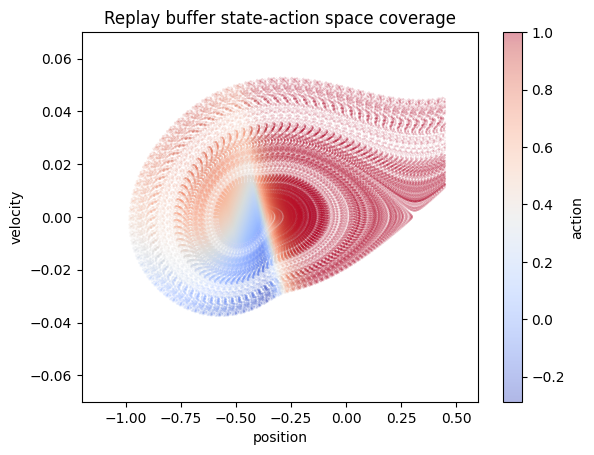

In [8]:
plot_rb_space_coverage(rb,state_x = (0, "position"), state_y = (1,"velocity"), state_space=state_space)

# Visualize learned policies

In [9]:
policies = torch.load(MODELS_DIR+"intermediate-policies.pt", weights_only=False)
policies.append(torch.load(MODELS_DIR+"best-policy.pt", weights_only=False))
policies = [item for item in policies if item is not None]

policies = dict(policies) # expected format is dict[reward, policy]

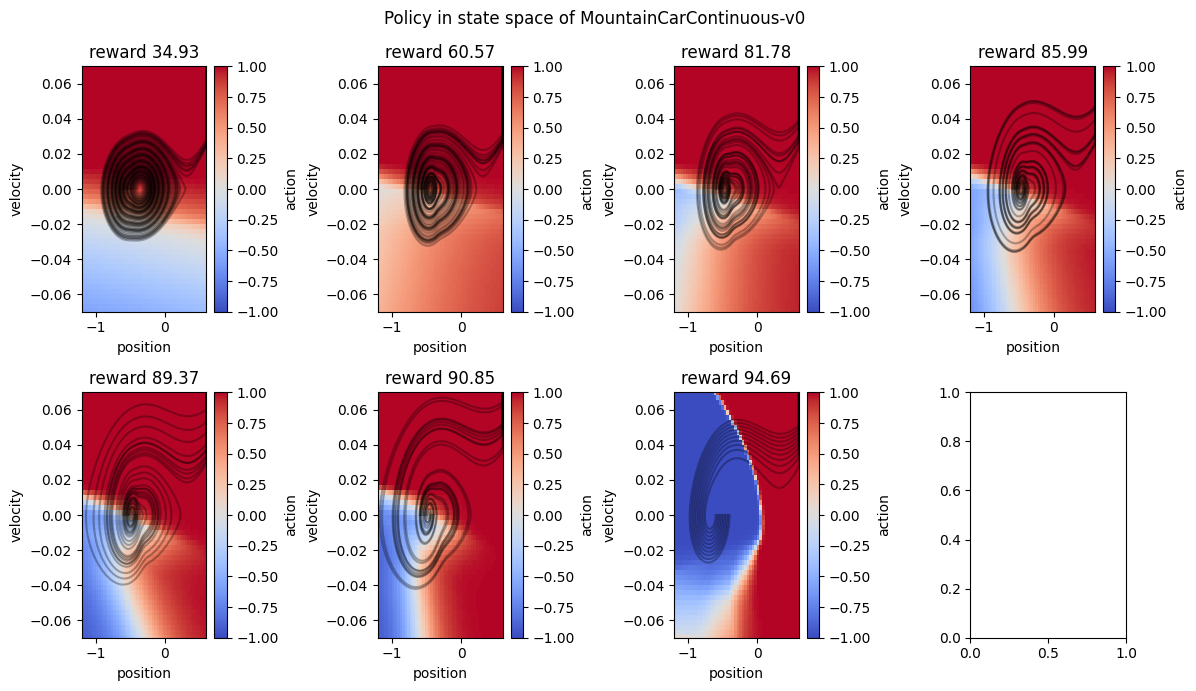

In [10]:
TRAJECTORY_LENGTH = 999
N_TRAJECTORIES = 10
start_states = np.vstack(
    [np.linspace(-0.6, -0.4, N_TRAJECTORIES), np.zeros(N_TRAJECTORIES)]
).T
fig, axes = plt.subplots(2, 4, figsize=(12, 7))
axes = axes.flatten()
for i, (reward, policy) in enumerate(sorted(policies.items())):
    plot_policy(
        policy,
        state_x=state_x,
        state_y=state_y,
        state_space=state_space,
        ax=axes[i],
    )

    plot_trajectories(
        env=env,
        policy=policy,
        init_space=init_space,
        nb_traj=N_TRAJECTORIES,
        traj_length=TRAJECTORY_LENGTH,
        ax=axes[i],
    )
    axes[i].set_title(f"reward {reward:.2f}")

plt.suptitle(f"Policy in state space of {ENV_NAME}")
plt.tight_layout()
plt.show()

# Visualize learned Q-values

## TODO: get critic as well, not only actor